Step 1: Loading and Preprocessing Data...
Loaded .mat file. Variables found: ['__header__', '__version__', '__globals__', 'dsfilt_emg', 'joint_angles']
Concatenated data shapes: EMG=(140000, 8), Angles=(140000, 14), Labels=(140000,)
Data scaling complete.

Data split: Train EMG=(112000, 8), Test EMG=(28000, 8)

Step 2: Defining Biomechanical Concepts...

--- Defining Concepts using PCA ---
Defined concept 'Thumb_FlexExt' using PCA (1st component shape: (8,))
Defined concept 'Index_FlexExt' using PCA (1st component shape: (8,))
Defined concept 'Middle_FlexExt' using PCA (1st component shape: (8,))
Defined concept 'Ring_FlexExt' using PCA (1st component shape: (8,))
Defined concept 'Little_FlexExt' using PCA (1st component shape: (8,))
Defined concept 'Simultaneous_FlexExt' using PCA (1st component shape: (8,))
Defined concept 'Random_FlexExt' using PCA (1st component shape: (8,))
Defined 7 concepts: ['Thumb_FlexExt', 'Index_FlexExt', 'Middle_FlexExt', 'Ring_FlexExt', 'Little_FlexExt', '

C:\Users\tamin\.conda\envs\py39\lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


t-SNE completed.


C:\Users\tamin\AppData\Local\Temp\ipykernel_17280\307361658.py:764: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', num_tasks) # Colormap for tasks


TypeError: alpha must be numeric or None, not <class 'numpy.ndarray'>

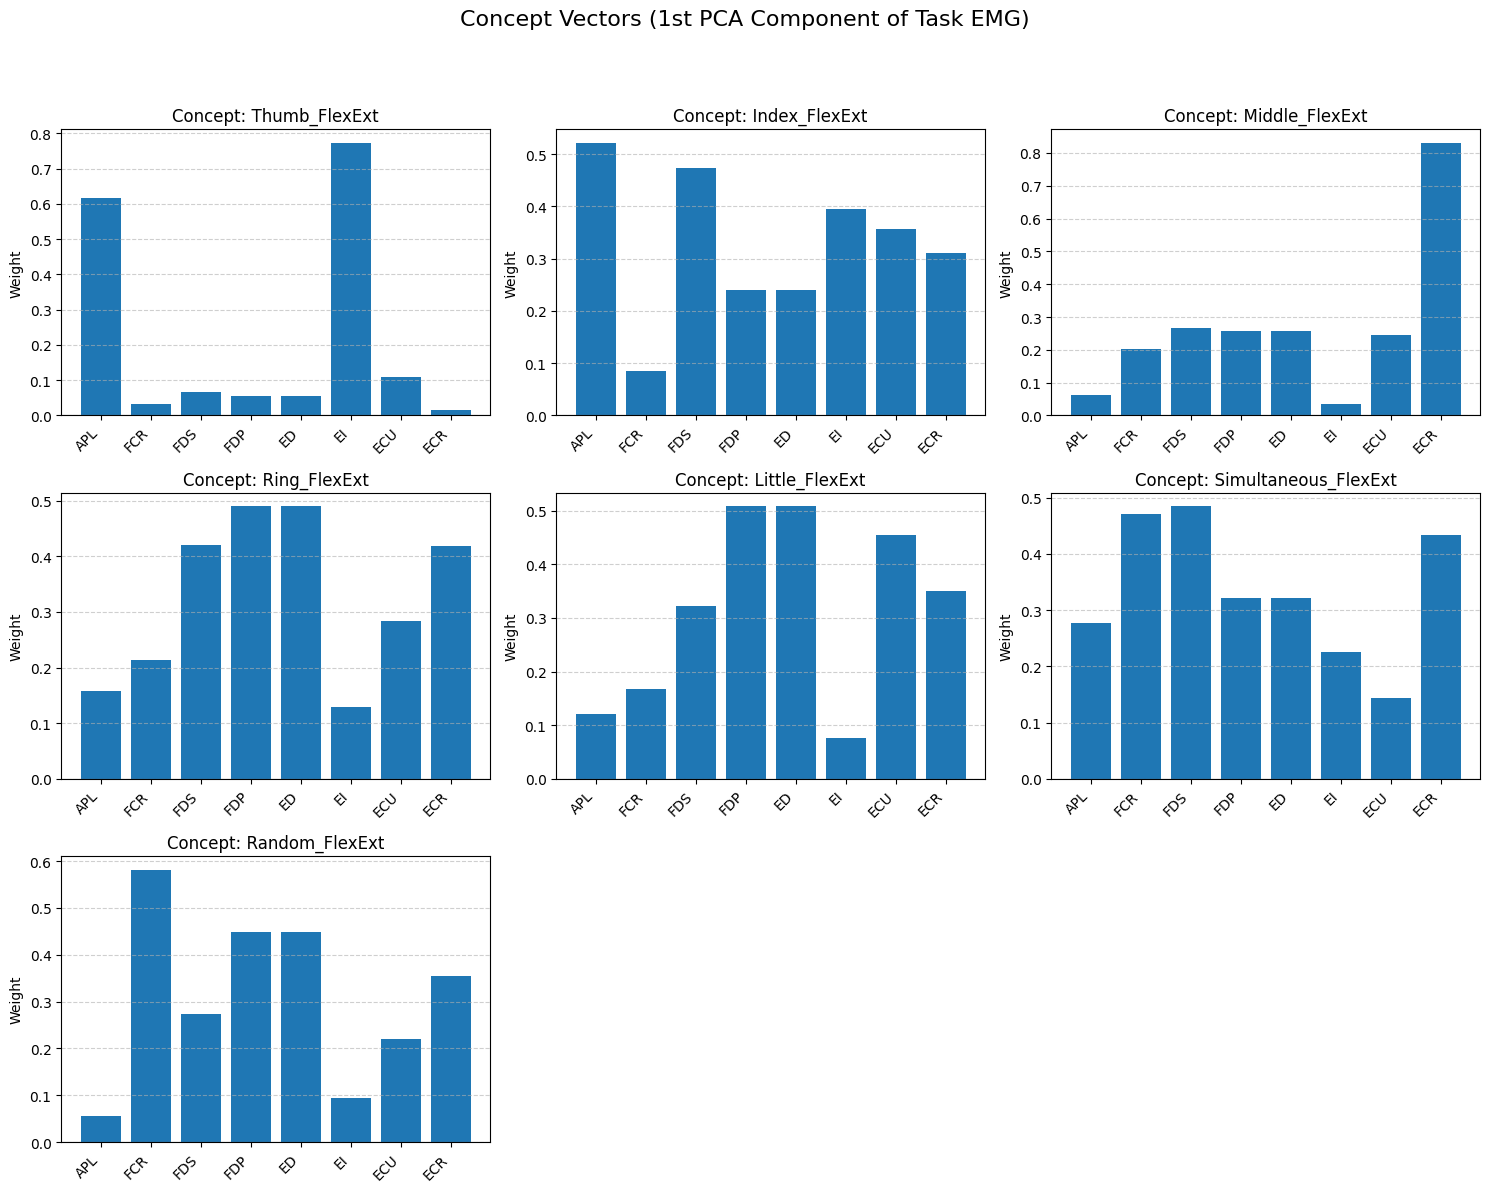

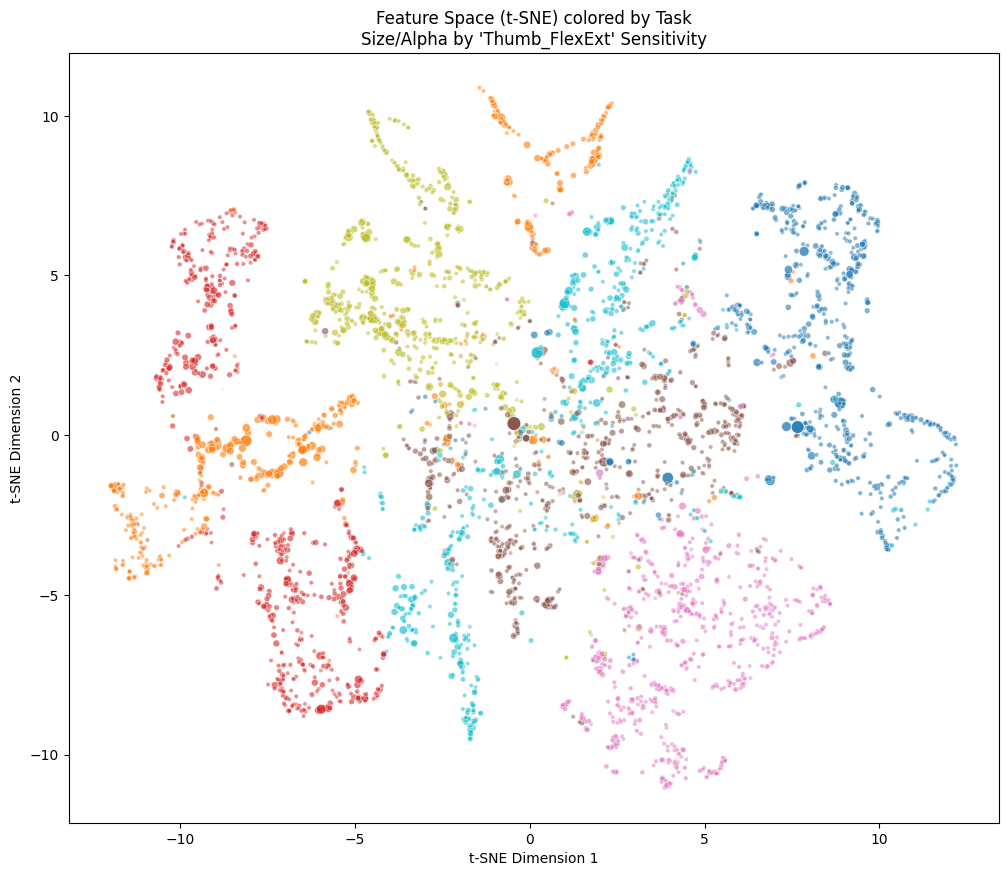

In [14]:
# -*- coding: utf-8 -*-
"""
Estimate joint angles from EMG using an MLP and explain using TCAV,
including visualizations for concepts, results, and feature space projection.

This script outlines the process:
1. Load and preprocess EMG and joint angle data from a .mat file.
2. Define biomechanical concepts (muscle synergies) using PCA on task-specific EMG.
3. Train an MLP regression model (EMG -> Joint Angles).
4. Train a task classifier on features extracted from the regression model.
5. Implement and apply TCAV to explain the task classifier's predictions based on the defined concepts.
6. Visualize the concepts, TCAV scores, derivative distributions, training history,
   and feature space projection with concept influence.
"""

import numpy as np
import scipy.io
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE # <-- Added for t-SNE visualization
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors # For color mapping
import os
import warnings
import math # For subplot grid calculation

# Suppress TensorFlow warnings for cleaner output
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
tf.get_logger().setLevel('ERROR')
warnings.filterwarnings('ignore', category=UserWarning, module='tensorflow')
warnings.filterwarnings('ignore', category=FutureWarning, module='tensorflow')
# Ignore specific UserWarning from Matplotlib about finding fonts
warnings.filterwarnings("ignore", message="Glyph.*missing from current font.", category=UserWarning)
# Ignore t-SNE convergence warning if needed (though default iterations are usually sufficient)
warnings.filterwarnings("ignore", message=".*t-SNE.*did not converge.*", category=UserWarning)


# --- 1. Data Loading and Preprocessing ---

def load_and_preprocess_data(mat_file_path, num_trials=5, num_tasks=7):
    """
    Loads data from the .mat file, handles the cell structure, and preprocesses.

    Args:
        mat_file_path (str): Path to the .mat file.
        num_trials (int): Number of trials (rows in cell array).
        num_tasks (int): Number of tasks (columns in cell array).

    Returns:
        tuple: (all_emg, all_angles, all_task_labels, emg_scaler, angle_scaler)
               - all_emg: Concatenated and scaled EMG data (samples, features).
               - all_angles: Concatenated and scaled joint angle data (samples, targets).
               - all_task_labels: Task label for each sample (samples,).
               - emg_scaler: Fitted scaler for EMG data.
               - angle_scaler: Fitted scaler for angle data.
               - task_data_indices: Dictionary mapping task_label to list of sample indices.
    """
    try:
        # Try loading with specific variable names if known
        mat_data = scipy.io.loadmat(mat_file_path, variable_names=['dsfilt_emg', 'joint_angles'])
        print(f"Loaded .mat file. Variables found: {list(mat_data.keys())}")
    except FileNotFoundError:
        print(f"Error: File not found at {mat_file_path}")
        print("Please provide the correct path to your .mat file.")
        # Returning dummy data for demonstration if file not found
        # Assign default scalers and empty indices dict for dummy data
        dummy_emg = np.random.rand(1000, 8)
        dummy_angles = np.random.rand(1000, 14)
        dummy_labels = np.random.randint(0, num_tasks, 1000)
        dummy_emg_scaler = StandardScaler().fit(dummy_emg)
        dummy_angle_scaler = MinMaxScaler().fit(dummy_angles)
        dummy_indices = {i: list(np.where(dummy_labels == i)[0]) for i in range(num_tasks)}
        return dummy_emg, dummy_angles, dummy_labels, dummy_emg_scaler, dummy_angle_scaler, dummy_indices
    except Exception as e:
        print(f"Error loading .mat file: {e}")
        return None, None, None, None, None, {}

    # Extract cell arrays (adjust keys if needed based on your .mat file)
    emg_cell = mat_data.get('dsfilt_emg', None)
    angles_cell = mat_data.get('joint_angles', None)
    # kinematics_cell = mat_data.get('finger_kinematics', None) # Not used directly for regression model

    if emg_cell is None or angles_cell is None:
        print("Error: Could not find 'dsfilt_emg' or 'joint_angles' variables in the .mat file.")
        # Try loading without specifying variables if the first attempt failed
        try:
            print("Attempting to load all variables...")
            mat_data = scipy.io.loadmat(mat_file_path)
            emg_cell = mat_data.get('dsfilt_emg', None)
            angles_cell = mat_data.get('joint_angles', None)
            if emg_cell is None or angles_cell is None:
                 print("Error: Still could not find required variables.")
                 return None, None, None, None, None, {}
            print(f"Loaded all variables. Found: {list(mat_data.keys())}")
        except Exception as e:
            print(f"Error loading all variables: {e}")
            return None, None, None, None, None, {}


    # Use actual shape from loaded data if possible
    actual_trials, actual_tasks = emg_cell.shape
    if (actual_trials, actual_tasks) != (num_trials, num_tasks):
         print(f"Warning: Unexpected cell array shape. Expected ({num_trials}, {num_tasks}), "
               f"got EMG: {emg_cell.shape}. Using actual shape ({actual_trials}, {actual_tasks}).")
         num_trials, num_tasks = actual_trials, actual_tasks


    all_emg = []
    all_angles = []
    all_task_labels = []
    task_data_indices = {i: [] for i in range(num_tasks)} # Task labels 0 to num_tasks-1
    current_index = 0

    for trial in range(num_trials):
        for task in range(num_tasks):
            try:
                # Check if the cell content exists and is a numpy array
                if trial < emg_cell.shape[0] and task < emg_cell.shape[1] and \
                   isinstance(emg_cell[trial, task], np.ndarray) and \
                   trial < angles_cell.shape[0] and task < angles_cell.shape[1] and \
                   isinstance(angles_cell[trial, task], np.ndarray):

                    emg_segment = emg_cell[trial, task]
                    angle_segment = angles_cell[trial, task]

                    # Further validation
                    if emg_segment.size == 0 or angle_segment.size == 0:
                         # print(f"Warning: Empty array in cell ({trial}, {task}). Skipping.") # Reduce verbosity
                         continue
                    if emg_segment.shape[0] != angle_segment.shape[0]:
                        print(f"Warning: Mismatched samples in cell ({trial}, {task}). "
                              f"EMG: {emg_segment.shape[0]}, Angles: {angle_segment.shape[0]}. Skipping.")
                        continue
                    # Handle cases where data might be 1D array (e.g., only one sample)
                    if emg_segment.ndim == 1: emg_segment = emg_segment.reshape(1, -1)
                    if angle_segment.ndim == 1: angle_segment = angle_segment.reshape(1, -1)

                    if emg_segment.ndim < 2 or emg_segment.shape[1] != 8:
                         print(f"Warning: Unexpected EMG shape in cell ({trial}, {task}). "
                               f"Expected (N, 8), got {emg_segment.shape}. Skipping.")
                         continue
                    if angle_segment.ndim < 2 or angle_segment.shape[1] != 14:
                         print(f"Warning: Unexpected Angle shape in cell ({trial}, {task}). "
                               f"Expected (N, 14), got {angle_segment.shape}. Skipping.")
                         continue


                    num_samples = emg_segment.shape[0]
                    all_emg.append(emg_segment)
                    all_angles.append(angle_segment)
                    task_label = task # Task index (0 to num_tasks-1)
                    all_task_labels.extend([task_label] * num_samples)
                    # task_data_indices[task_label].extend(range(current_index, current_index + num_samples)) # Indices calculation moved after concat
                    current_index += num_samples
                # else:
                    # print(f"Warning: Invalid or non-array data in cell ({trial}, {task}). Skipping.") # Reduce verbosity


            except IndexError:
                print(f"Warning: Cell ({trial}, {task}) index out of bounds. Skipping.")
            except Exception as e:
                 print(f"Error processing cell ({trial}, {task}): {e}. Skipping.")


    if not all_emg:
        print("Error: No valid data segments found after processing cells.")
        return None, None, None, None, None, {}

    all_emg = np.concatenate(all_emg, axis=0)
    all_angles = np.concatenate(all_angles, axis=0)
    all_task_labels = np.array(all_task_labels)

    # Check if concatenation resulted in empty arrays
    if all_emg.size == 0 or all_angles.size == 0:
         print("Error: Concatenated data is empty.")
         return None, None, None, None, None, {}

    print(f"Concatenated data shapes: EMG={all_emg.shape}, Angles={all_angles.shape}, Labels={all_task_labels.shape}")

    # --- Scaling ---
    # Scale EMG signals (StandardScaler is often good for signals)
    emg_scaler = StandardScaler()
    all_emg_scaled = emg_scaler.fit_transform(all_emg)

    # Scale Angles (MinMaxScaler to [0, 1] or [-1, 1] is common for angles)
    angle_scaler = MinMaxScaler(feature_range=(0, 1)) # Matches sigmoid output
    all_angles_scaled = angle_scaler.fit_transform(all_angles)

    print("Data scaling complete.")

    # Update task_data_indices based on the final concatenated labels
    final_task_data_indices = {i: list(np.where(all_task_labels == i)[0]) for i in range(num_tasks)}


    return all_emg_scaled, all_angles_scaled, all_task_labels, emg_scaler, angle_scaler, final_task_data_indices

# --- 2. Concept Definition (using PCA on Task-Specific EMG) ---

def define_concepts_pca(emg_data, task_labels, task_data_indices, num_tasks, n_components=3):
    """
    Defines concepts (synergies) by applying PCA to EMG data for specific tasks.

    Args:
        emg_data (np.ndarray): Scaled EMG data (samples, features=8).
        task_labels (np.ndarray): Task label for each sample.
        task_data_indices (dict): Mapping task_label to list of sample indices.
        num_tasks (int): Total number of tasks expected.
        n_components (int): Number of principal components to represent the synergy.

    Returns:
        tuple: (concepts, task_names)
               - concepts (dict): {concept_name: concept_vector}
               - task_names (list): List of names corresponding to task indices.
               Returns (None, None) if no concepts are defined.
    """
    concepts = {}
    # Task names corresponding to task indices 0-6 (adjust if num_tasks differs)
    default_task_names = [
        "Thumb_FlexExt", "Index_FlexExt", "Middle_FlexExt", "Ring_FlexExt",
        "Little_FlexExt", "Simultaneous_FlexExt", "Random_FlexExt"
    ]
    # Use default names up to num_tasks, or generic names if more tasks
    task_names = [default_task_names[i] if i < len(default_task_names) else f"Task_{i+1}" for i in range(num_tasks)]


    print("\n--- Defining Concepts using PCA ---")
    for task_idx, task_name in enumerate(task_names):
        indices = task_data_indices.get(task_idx, [])
        # Ensure indices are within the bounds of emg_data
        indices = [i for i in indices if i < len(emg_data)]

        min_samples_needed = max(n_components * 2, emg_data.shape[1] + 1) # Heuristic for PCA stability
        if len(indices) < min_samples_needed:
            print(f"Skipping concept '{task_name}': Insufficient data samples ({len(indices)} < {min_samples_needed}).")
            continue

        task_emg = emg_data[indices]

        # Check again if task_emg is valid after indexing
        if task_emg.shape[0] < n_components or task_emg.shape[0] < task_emg.shape[1]:
             print(f"Skipping concept '{task_name}': Not enough samples ({task_emg.shape[0]}) after indexing for PCA.")
             continue


        try:
            # Ensure n_components is not larger than number of samples or features
            actual_n_components = min(n_components, task_emg.shape[0], task_emg.shape[1])
            if actual_n_components < 1:
                 print(f"Skipping concept '{task_name}': Cannot perform PCA with n_components={actual_n_components}.")
                 continue

            pca = PCA(n_components=actual_n_components)
            pca.fit(task_emg)
            # Concept vector: Use the first principal component as the representative direction
            # This vector lives in the 8-dimensional EMG feature space
            concept_vector = pca.components_[0]
            concepts[task_name] = concept_vector
            print(f"Defined concept '{task_name}' using PCA (1st component shape: {concept_vector.shape})")
        except Exception as e:
            print(f"Error applying PCA for task '{task_name}': {e}")

    if not concepts:
         print("Warning: No concepts could be defined. Check data sufficiency per task.")
         return None, None

    # Ensure task_names list matches the number of tasks potentially defined
    final_task_names = [tn for i, tn in enumerate(task_names) if i in [task_name_to_idx(cn, task_names) for cn in concepts.keys()]]


    return concepts, task_names # Return task_names as well

def task_name_to_idx(concept_name, task_names_list):
    """Helper to find index for a concept name."""
    try:
        return task_names_list.index(concept_name)
    except ValueError:
        return None

def get_concept_examples(emg_data, task_labels, task_data_indices, target_task_idx, num_examples=100):
    """
    Gets positive examples (data belonging to the concept's task) and negative examples (random data).

    Args:
        emg_data (np.ndarray): Scaled EMG data.
        task_labels (np.ndarray): Task labels.
        task_data_indices (dict): Mapping task_label to indices.
        target_task_idx (int): The task index the concept is based on.
        num_examples (int): Number of positive examples to retrieve.

    Returns:
        tuple: (positive_examples, negative_examples) or (None, None) if insufficient data.
               Negative examples are currently not used in score calc but retrieved.
    """
    positive_indices = task_data_indices.get(target_task_idx, [])
    # Ensure indices are valid
    positive_indices = [i for i in positive_indices if i < len(emg_data)]


    if len(positive_indices) < num_examples // 2 and len(positive_indices) > 0: # Need at least some positive examples
        print(f"Warning: Fewer positive examples than requested for task {target_task_idx} ({len(positive_indices)} found). Using available.")
        num_pos_to_sample = len(positive_indices)
    elif len(positive_indices) == 0:
         print(f"Warning: No positive examples found for task {target_task_idx}.")
         return None, None
    else:
        num_pos_to_sample = min(num_examples, len(positive_indices))


    pos_indices_sample = np.random.choice(positive_indices, num_pos_to_sample, replace=False)
    positive_examples = emg_data[pos_indices_sample]

    # Get negative examples (randomly sampled from *other* tasks) - Optional for current score calc
    all_indices = np.arange(len(emg_data))
    negative_pool_indices = np.setdiff1d(all_indices, positive_indices)
    negative_examples = None
    if len(negative_pool_indices) > 0:
         num_neg_to_sample = min(num_examples, len(negative_pool_indices))
         neg_indices_sample = np.random.choice(negative_pool_indices, num_neg_to_sample, replace=False)
         negative_examples = emg_data[neg_indices_sample]
    else:
        print(f"Warning: No negative examples pool found for task {target_task_idx}.")


    if positive_examples.size == 0: positive_examples = None
    if negative_examples is not None and negative_examples.size == 0: negative_examples = None


    return positive_examples, negative_examples


# --- 3. Model Training (EMG -> Joint Angles Regression) ---

def build_regression_model(input_shape, output_shape, intermediate_layer_name='feature_layer'):
    """Builds a simple MLP model for EMG to Joint Angle regression."""
    model = keras.Sequential(name="EMG_to_Angle_Regressor")
    model.add(layers.Input(shape=(input_shape,), name="EMG_Input"))
    model.add(layers.Dense(64, activation='relu', name="Dense_1"))
    model.add(layers.Dropout(0.2))
    model.add(layers.Dense(128, activation='relu', name="Dense_2"))
    # Define the intermediate layer for feature extraction
    model.add(layers.Dense(64, activation='relu', name=intermediate_layer_name))
    model.add(layers.Dropout(0.2))
    model.add(layers.Dense(output_shape, activation='sigmoid', name="Angle_Output")) # Sigmoid activation for [0, 1] scaled angles

    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                  loss='mse', # Mean Squared Error for regression
                  metrics=['mae']) # Mean Absolute Error
    print("\n--- Regression Model Summary ---")
    model.summary(line_length=100)
    return model

# --- 4. Feature Extraction & Task Classification ---

def build_task_classifier(input_shape, num_tasks):
    """Builds a simple classifier on top of extracted features."""
    model = keras.Sequential(name="Task_Classifier")
    model.add(layers.Input(shape=(input_shape,), name="Feature_Input"))
    model.add(layers.Dense(32, activation='relu', name="Classifier_Dense_1"))
    model.add(layers.Dense(num_tasks, activation='softmax', name="Task_Output")) # Softmax for multi-class classification

    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy', # Use sparse CE for integer labels
                  metrics=['accuracy'])
    print("\n--- Task Classifier Model Summary ---")
    model.summary(line_length=100)
    return model

def extract_features(regression_model, layer_name, data):
    """Extracts features from an intermediate layer of the regression model."""
    try:
        feature_extractor_model = keras.Model(
            inputs=regression_model.input,
            outputs=regression_model.get_layer(layer_name).output,
            name="Feature_Extractor"
        )
    except ValueError:
        print(f"Error: Layer '{layer_name}' not found in the regression model.")
        # Fallback: Try extracting from the second to last layer if possible
        if len(regression_model.layers) > 1:
             fallback_layer = regression_model.layers[-2].name
             print(f"Attempting to use fallback layer: '{fallback_layer}'")
             try:
                  feature_extractor_model = keras.Model(
                      inputs=regression_model.input,
                      outputs=regression_model.get_layer(fallback_layer).output,
                      name="Feature_Extractor_Fallback"
                  )
             except Exception as e:
                  print(f"Fallback failed: {e}")
                  return None
        else:
             print("Cannot extract features, model has too few layers.")
             return None


    # Predict in batches to avoid potential memory issues with large datasets
    batch_size = 1024
    num_samples = data.shape[0]
    features = []
    print(f"Extracting features from {num_samples} samples...")
    progbar = keras.utils.Progbar(num_samples)
    for i in range(0, num_samples, batch_size):
        batch_data = data[i:min(i + batch_size, num_samples)]
        batch_features = feature_extractor_model.predict(batch_data, verbose=0)
        features.append(batch_features)
        progbar.update(i + batch_data.shape[0])

    if not features:
         return None

    features = np.concatenate(features, axis=0)
    print(f"\nExtracted features using layer '{feature_extractor_model.output.name.split('/')[0]}', shape: {features.shape}")
    return features


# --- 5. TCAV Implementation ---

def calculate_directional_derivative(model, layer_name, inputs, concept_vector, batch_size=512):
    """
    Calculates the dot product between the gradient of a layer's activation
    with respect to the input and the concept vector, processing in batches.

    Args:
        model (keras.Model): The model containing the layer.
        layer_name (str): Name of the layer whose activations' sensitivity is measured.
        inputs (np.ndarray or tf.Tensor): Input data to the model.
        concept_vector (np.ndarray): The concept vector (must match model's input feature dim).
        batch_size (int): Batch size for processing to manage memory.

    Returns:
        np.ndarray: Directional derivatives for each input sample.
                    Returns None if layer not found or shapes mismatch or gradient calculation fails.
    """
    try:
        target_layer = model.get_layer(layer_name)
        intermediate_model = keras.Model(model.inputs, target_layer.output)
    except ValueError:
        print(f"Error: Layer '{layer_name}' not found in the model '{model.name}'.")
        return None

    # Ensure concept_vector is a flat numpy array before checking shape
    concept_vector = np.array(concept_vector).flatten()

    # Check shape compatibility: model's input vs concept vector
    model_input_shape = model.input_shape[-1]
    if model_input_shape != concept_vector.shape[0]:
         print(f"Error: Model '{model.name}' input feature dimension ({model_input_shape}) "
               f"does not match concept vector dimension ({concept_vector.shape[0]}).")
         return None

    # Ensure concept_vector is a tf.Tensor
    concept_vector_tf = tf.cast(tf.constant(concept_vector), dtype=tf.float32)

    num_samples = inputs.shape[0]
    all_derivatives = []
    print(f"Calculating derivatives for {num_samples} samples...")
    progbar = keras.utils.Progbar(num_samples)

    for i in range(0, num_samples, batch_size):
        batch_inputs = inputs[i:min(i + batch_size, num_samples)]
        # Ensure batch_inputs is a tf.Tensor
        if not isinstance(batch_inputs, tf.Tensor):
            batch_inputs_tf = tf.convert_to_tensor(batch_inputs, dtype=tf.float32)
        else:
            batch_inputs_tf = batch_inputs

        with tf.GradientTape() as tape:
            tape.watch(batch_inputs_tf)
            # Get activations of the target layer
            activations = intermediate_model(batch_inputs_tf, training=False) # Shape: (batch, activation_units)
            # Sum activations across the units dimension for each sample in the batch.
            sum_activations = tf.reduce_sum(activations, axis=list(range(1, tf.rank(activations)))) # Sum over all non-batch dims

        # Calculate gradients: d(sum_activations) / d(inputs)
        gradients = tape.gradient(sum_activations, batch_inputs_tf)

        if gradients is None:
            print(f"\nWarning: Could not compute gradients for layer '{layer_name}' in model '{model.name}' (batch starting at {i}). "
                  "Check model connectivity or input values.")
            # Return None early if gradients fail for any batch
            return None

        # Project gradient onto the concept vector (dot product)
        batch_derivatives = tf.tensordot(gradients, concept_vector_tf, axes=1)
        all_derivatives.append(batch_derivatives.numpy())
        progbar.update(i + batch_inputs_tf.shape[0]) # Update progress bar

    if not all_derivatives:
        return None

    print("\nDerivative calculation complete.")
    return np.concatenate(all_derivatives, axis=0)


def calculate_tcav_score_and_derivatives(model, layer_name, concept_vector, positive_examples):
    """
    Calculates the TCAV score and returns the raw directional derivatives FOR POSITIVE EXAMPLES.

    Args:
        model (keras.Model): The model to analyze (e.g., regression model).
        layer_name (str): The layer whose activation sensitivity is measured (e.g., feature_layer).
        concept_vector (np.ndarray): The vector representing the concept (in model's input space).
        positive_examples (np.ndarray): Data examples WITH the concept.

    Returns:
        tuple: (tcav_score, derivatives)
               - tcav_score (float): Proportion of positive examples with positive derivative.
               - derivatives (np.ndarray): The raw directional derivatives for positive examples.
               Returns (None, None) if calculation fails.
    """
    if positive_examples is None or positive_examples.size == 0:
        print("Error: Missing or empty positive examples for TCAV score calculation.")
        return None, None

    print(f"\nCalculating TCAV score for concept vector shape: {concept_vector.shape}")
    print(f"Using {positive_examples.shape[0]} positive examples.")
    print(f"Analyzing sensitivity of layer '{layer_name}' in model '{model.name}' w.r.t. model input.")

    # Calculate directional derivatives for positive examples ONLY
    dir_derivatives_pos = calculate_directional_derivative(
        model, layer_name, positive_examples, concept_vector
    )

    if dir_derivatives_pos is None:
        print("Failed to calculate directional derivatives for positive examples.")
        return None, None

    # TCAV score: Proportion of positive examples with positive directional derivative
    tcav_score = np.mean(dir_derivatives_pos > 0)
    derivatives_np = dir_derivatives_pos # Already a numpy array

    return tcav_score, derivatives_np


# --- 6. Visualization Functions ---

def plot_concept_vectors(concepts, emg_channels):
    """Plots the concept vectors (PCA components) as bar charts."""
    if not concepts:
        print("No concepts to plot.")
        return

    num_concepts = len(concepts)
    if num_concepts == 0: return

    # Dynamic subplot grid
    cols = math.ceil(math.sqrt(num_concepts))
    rows = math.ceil(num_concepts / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows), squeeze=False)
    axes = axes.flatten() # Flatten to 1D array for easy iteration

    concept_names = list(concepts.keys())
    for i, name in enumerate(concept_names):
        vector = concepts[name]
        ax = axes[i]
        ax.bar(range(len(vector)), vector)
        ax.set_title(f"Concept: {name}")
        ax.set_ylabel("Weight")
        ax.set_xticks(range(len(vector)))
        ax.set_xticklabels(emg_channels, rotation=45, ha='right')
        ax.axhline(0, color='grey', linewidth=0.8) # Add horizontal line at 0
        ax.grid(axis='y', linestyle='--', alpha=0.6)

    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle("Concept Vectors (1st PCA Component of Task EMG)", fontsize=16, y=1.02)
    plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout
    # plt.show() # Show plots together later


def plot_tcav_scores(tcav_results, intermediate_layer_name):
    """Plots the TCAV scores as a bar chart."""
    if not tcav_results:
        print("No TCAV results to plot.")
        return

    names = list(tcav_results.keys())
    scores = list(tcav_results.values())

    plt.figure(figsize=(10, 6))
    bars = plt.bar(names, scores, color=plt.cm.get_cmap('viridis', len(scores))(np.linspace(0, 1, len(scores))))
    plt.ylabel("TCAV Score")
    plt.title(f"TCAV Scores (Sensitivity of '{intermediate_layer_name}' to Concepts)")
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0, 1.05) # TCAV score is between 0 and 1
    plt.axhline(0.5, color='grey', linestyle='--', linewidth=0.8, label='Baseline (0.5)')
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()

    # Add score labels on top of bars
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.01, f'{yval:.3f}', va='bottom', ha='center') # Added formatting

    # plt.show() # Show plots together later


def plot_directional_derivatives(tcav_derivatives_positive):
    """Plots histograms of directional derivatives for each concept's positive examples."""
    if not tcav_derivatives_positive:
        print("No positive derivative data to plot.")
        return

    num_concepts = len(tcav_derivatives_positive)
    if num_concepts == 0: return

     # Dynamic subplot grid
    cols = math.ceil(math.sqrt(num_concepts))
    rows = math.ceil(num_concepts / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows), squeeze=False)
    axes = axes.flatten()

    concept_names = list(tcav_derivatives_positive.keys())
    for i, name in enumerate(concept_names):
        derivatives = tcav_derivatives_positive[name]
        ax = axes[i] # Get current axis

        if derivatives is None or derivatives.size == 0:
            print(f"No positive derivatives to plot for concept '{name}'.")
            ax.set_title(f"{name}\n(No data)")
            ax.text(0.5, 0.5, 'No derivative data', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)
            continue

        ax.hist(derivatives, bins=20, alpha=0.7, density=True) # Use density=True for better comparison
        ax.set_title(f"Derivatives: {name}")
        ax.set_xlabel("Directional Derivative Value")
        ax.set_ylabel("Density")
        ax.axvline(0, color='red', linestyle='--', linewidth=1.0, label='Zero') # Mark zero point
        # Calculate TCAV score from derivatives again for annotation
        score = np.mean(derivatives > 0)
        ax.text(0.95, 0.95, f'TCAV Score: {score:.3f}', transform=ax.transAxes,
                verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='round,pad=0.3', fc='wheat', alpha=0.8)) # Changed background color
        ax.legend()
        ax.grid(axis='y', linestyle='--', alpha=0.6)

     # Hide unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])


    plt.suptitle("Distribution of Directional Derivatives (Positive Examples)", fontsize=16, y=1.02)
    plt.tight_layout(rect=[0, 0.03, 1, 0.98])
    # plt.show() # Show plots together later

def plot_training_history(history_reg, history_clf):
    """Plots the training history for regression and classification models."""
    plt.figure(figsize=(14, 6))

    # Regression History
    plt.subplot(1, 2, 1)
    if hasattr(history_reg, 'history') and 'loss' in history_reg.history and 'val_loss' in history_reg.history:
        plt.plot(history_reg.history['loss'], label='Train Loss (MSE)')
        plt.plot(history_reg.history['val_loss'], label='Val Loss (MSE)')
        plt.title('Regression Model Loss')
        plt.xlabel('Epoch')
        plt.ylabel('MSE')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.6)
    else:
        plt.title('Regression Model Loss (No Data)')
        plt.text(0.5, 0.5, 'No training history data', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes)


    # Classification History
    plt.subplot(1, 2, 2)
    if hasattr(history_clf, 'history') and 'accuracy' in history_clf.history and 'val_accuracy' in history_clf.history:
        plt.plot(history_clf.history['accuracy'], label='Train Accuracy')
        plt.plot(history_clf.history['val_accuracy'], label='Val Accuracy')
        plt.title('Task Classifier Accuracy')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.6)
    else:
         plt.title('Task Classifier Accuracy (No Data)')
         plt.text(0.5, 0.5, 'No training history data', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes)


    plt.suptitle("Model Training History", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout for suptitle
    # plt.show() # Show plots together later


def plot_feature_space_projection(features, labels, num_tasks, task_names,
                                  concept_name, derivatives,
                                  max_points=5000, random_state=None):
    """
    Performs t-SNE and plots feature space projection with concept sensitivity.

    Args:
        features (np.ndarray): High-dimensional feature vectors.
        labels (np.ndarray): Task labels corresponding to features.
        num_tasks (int): Total number of unique tasks.
        task_names (list): List of names for task labels.
        concept_name (str): Name of the concept being visualized.
        derivatives (np.ndarray): Directional derivatives corresponding to features.
        max_points (int): Maximum number of points to use for t-SNE and plotting.
        random_state (int, optional): Random seed for reproducibility.
    """
    if features is None or labels is None or derivatives is None:
        print(f"Skipping feature space plot for '{concept_name}': Missing data.")
        return
    if features.shape[0] != labels.shape[0] or features.shape[0] != derivatives.shape[0]:
        print(f"Skipping feature space plot for '{concept_name}': Mismatched shapes.")
        print(f"Features: {features.shape}, Labels: {labels.shape}, Derivatives: {derivatives.shape}")
        return

    n_samples = features.shape[0]
    indices = np.arange(n_samples)

    if n_samples > max_points:
        print(f"Subsampling data from {n_samples} to {max_points} points for t-SNE...")
        if random_state is not None:
            np.random.seed(random_state)
        indices = np.random.choice(indices, max_points, replace=False)

    features_subset = features[indices]
    labels_subset = labels[indices]
    derivatives_subset = derivatives[indices]

    print(f"Running t-SNE on {features_subset.shape[0]} points...")
    tsne = TSNE(n_components=2, random_state=random_state, perplexity=min(30, features_subset.shape[0]-1), n_iter=300, init='pca', learning_rate='auto')
    try:
        features_2d = tsne.fit_transform(features_subset)
        print("t-SNE completed.")
    except Exception as e:
        print(f"Error during t-SNE: {e}. Skipping feature space plot for '{concept_name}'.")
        return


    plt.figure(figsize=(12, 10))

    # --- Map derivatives to size and alpha ---
    # Normalize positive derivatives for size scaling (e.g., from 0 to 1)
    pos_derivatives = derivatives_subset[derivatives_subset > 0]
    sizes = np.full(derivatives_subset.shape, 10) # Default size
    if len(pos_derivatives) > 0:
        scaler = MinMaxScaler(feature_range=(0, 1))
        # Handle potential single value case for scaler
        if pos_derivatives.ndim == 1: pos_derivatives = pos_derivatives.reshape(-1, 1)
        scaled_pos_derivatives = scaler.fit_transform(pos_derivatives).flatten()
        # Map scaled values to a size range (e.g., 10 to 100)
        sizes[derivatives_subset > 0] = 10 + scaled_pos_derivatives * 90

    # Use derivatives for alpha (e.g., more sensitive = less transparent)
    # Normalize all derivatives (e.g., to [0.1, 1.0])
    alpha_scaler = MinMaxScaler(feature_range=(0.1, 1.0))
    # Handle potential single value case for scaler
    if derivatives_subset.ndim == 1: derivatives_subset_reshape = derivatives_subset.reshape(-1, 1)
    else: derivatives_subset_reshape = derivatives_subset
    alphas = alpha_scaler.fit_transform(derivatives_subset_reshape).flatten()

    # --- Create Scatter Plot ---
    cmap = plt.cm.get_cmap('tab10', num_tasks) # Colormap for tasks
    scatter = plt.scatter(features_2d[:, 0], features_2d[:, 1],
                          c=labels_subset, cmap=cmap,
                          s=sizes, alpha=alphas, edgecolors='w', linewidth=0.5)

    plt.title(f"Feature Space (t-SNE) colored by Task\nSize/Alpha by '{concept_name}' Sensitivity")
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")

    # Create legend for task colors
    handles, _ = scatter.legend_elements(prop='colors', num=num_tasks)
    # Ensure task_names matches the number of unique labels present in the subset
    unique_labels_in_subset = np.unique(labels_subset)
    legend_labels = [task_names[i] for i in unique_labels_in_subset if i < len(task_names)]
    if len(handles) == len(legend_labels):
         plt.legend(handles, legend_labels, title="Tasks", bbox_to_anchor=(1.05, 1), loc='upper left')
    else:
         print("Warning: Mismatch between legend handles and labels. Skipping legend.")


    plt.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust layout for legend
    # plt.show() # Show plots together later


# --- Main Execution ---

if __name__ == "__main__":
    # --- Configuration ---
    MAT_FILE_PATH = 's4_full.mat' # <<< IMPORTANT: SET THIS PATH! If file not found, uses dummy data.
    NUM_TRIALS = 5 # Expected trials, will be updated if file has different shape
    NUM_TASKS = 7  # Expected tasks, will be updated if file has different shape
    CONCEPT_PCA_COMPONENTS = 3 # Number of PCA components for synergy concepts
    REGRESSION_EPOCHS = 30 # Increased epochs
    CLASSIFIER_EPOCHS = 20 # Increased epochs
    TEST_SPLIT_RATIO = 0.2
    RANDOM_SEED = 42
    INTERMEDIATE_LAYER = 'feature_layer' # Must match name in build_regression_model
    # Define EMG channel names based on data description
    EMG_CHANNEL_NAMES = ['APL', 'FCR', 'FDS', 'FDP', 'ED', 'EI', 'ECU', 'ECR']
    TSNE_MAX_POINTS = 5000 # Max points for t-SNE visualization


    np.random.seed(RANDOM_SEED)
    tf.random.set_seed(RANDOM_SEED)

    # --- 1. Load Data ---
    print("Step 1: Loading and Preprocessing Data...")
    emg_scaled, angles_scaled, task_labels, emg_scaler, angle_scaler, task_data_indices = \
        load_and_preprocess_data(MAT_FILE_PATH, NUM_TRIALS, NUM_TASKS)

    if emg_scaled is None:
        print("Exiting due to data loading errors.")
        exit()

    # Update NUM_TASKS based on loaded data if it changed
    loaded_num_tasks = len(task_data_indices)
    if loaded_num_tasks != NUM_TASKS:
        print(f"Adjusting NUM_TASKS from {NUM_TASKS} to {loaded_num_tasks} based on loaded data.")
        NUM_TASKS = loaded_num_tasks


    # --- Split Data (Train/Test for Regression Model) ---
    # Ensure stratification is possible
    unique_labels, counts = np.unique(task_labels, return_counts=True)
    min_samples_per_class = counts.min() if len(counts) > 0 else 0

    if min_samples_per_class < 2 and len(unique_labels) > 1:
        print(f"Warning: Minimum class count ({min_samples_per_class}) is too low for stratification. Splitting without stratify.")
        stratify_labels = None
    else:
        stratify_labels = task_labels

    try:
        X_train_reg, X_test_reg, y_train_reg, y_test_reg, labels_train_reg, labels_test_reg = train_test_split(
            emg_scaled, angles_scaled, task_labels,
            test_size=TEST_SPLIT_RATIO,
            random_state=RANDOM_SEED,
            stratify=stratify_labels
        )
        print(f"\nData split: Train EMG={X_train_reg.shape}, Test EMG={X_test_reg.shape}")
    except ValueError as e:
         print(f"Error during train_test_split (possibly due to low class counts): {e}")
         print("Attempting split without stratification.")
         X_train_reg, X_test_reg, y_train_reg, y_test_reg, labels_train_reg, labels_test_reg = train_test_split(
            emg_scaled, angles_scaled, task_labels, test_size=TEST_SPLIT_RATIO, random_state=RANDOM_SEED
         )
         print(f"\nData split (unstratified): Train EMG={X_train_reg.shape}, Test EMG={X_test_reg.shape}")


    # --- 2. Define Concepts ---
    print("\nStep 2: Defining Biomechanical Concepts...")
    # Use only TRAINING EMG data to define concepts to avoid data leakage
    # Recalculate task indices for the training set
    train_task_data_indices = {i: list(np.where(labels_train_reg == i)[0]) for i in range(NUM_TASKS)}

    concepts, task_names = define_concepts_pca(X_train_reg, labels_train_reg, train_task_data_indices, NUM_TASKS, CONCEPT_PCA_COMPONENTS)

    if not concepts:
        print("Warning: Could not define concepts. TCAV analysis will be skipped.")
    else:
        print(f"Defined {len(concepts)} concepts: {list(concepts.keys())}")
        # Visualize Concepts
        plot_concept_vectors(concepts, EMG_CHANNEL_NAMES)


    # --- 3. Train Regression Model ---
    print("\nStep 3: Training EMG -> Joint Angle Regression Model...")
    regression_model = build_regression_model(X_train_reg.shape[1], y_train_reg.shape[1], INTERMEDIATE_LAYER)

    history_reg = regression_model.fit(
        X_train_reg, y_train_reg,
        epochs=REGRESSION_EPOCHS,
        batch_size=64,
        validation_split=0.2, # Use part of training data for validation during training
        verbose=1 # Set to 1 or 2 to see progress, 0 for silent
    )

    # Evaluate Regression Model
    loss_reg, mae_reg = regression_model.evaluate(X_test_reg, y_test_reg, verbose=0)
    print(f"\nRegression Model Test Performance: Loss (MSE)={loss_reg:.4f}, MAE={mae_reg:.4f}")

    # --- 4. Extract Features & Train Task Classifier ---
    print("\nStep 4: Extracting Features and Training Task Classifier...")
    # Extract features from the intermediate layer for both train and test sets
    features_train = extract_features(regression_model, INTERMEDIATE_LAYER, X_train_reg)
    features_test = extract_features(regression_model, INTERMEDIATE_LAYER, X_test_reg)

    if features_train is None or features_test is None:
        print("Exiting due to feature extraction errors.")
        # Attempt to plot training history even if feature extraction failed
        if 'history_reg' in locals():
             plot_training_history(history_reg, None) # Plot only regression history
             plt.show() # Show the plot now
        exit()

    # Build and train the classifier
    task_classifier = build_task_classifier(features_train.shape[1], NUM_TASKS)
    history_clf = task_classifier.fit(
        features_train, labels_train_reg,
        epochs=CLASSIFIER_EPOCHS,
        batch_size=64,
        validation_data=(features_test, labels_test_reg), # Use test set for classifier validation
        verbose=1
    )

    # Evaluate Task Classifier
    loss_clf, acc_clf = task_classifier.evaluate(features_test, labels_test_reg, verbose=0)
    print(f"\nTask Classifier Test Performance: Loss={loss_clf:.4f}, Accuracy={acc_clf:.4f}")


    # --- 5. Perform TCAV Analysis & Feature Space Visualization ---
    print("\nStep 5: Performing TCAV Analysis & Feature Space Visualization...")

    if not concepts:
        print("Skipping TCAV and Feature Space Viz as no concepts were defined.")
        tcav_results = {}
        tcav_derivatives_positive = {}
    else:
        tcav_results = {}
        tcav_derivatives_positive = {} # Store raw derivatives for positive examples for histogram plot
        all_concept_derivatives_train = {} # Store derivatives for ALL train samples for t-SNE plot

        for concept_name, concept_vector in concepts.items():
            print(f"\n--- Analyzing Concept: {concept_name} ---")
            target_task_idx = task_name_to_idx(concept_name, task_names) # Use helper function

            if target_task_idx is None:
                print(f"Warning: Could not find task index for concept '{concept_name}'. Skipping.")
                continue

            # --- Calculate TCAV Score (using positive examples) ---
            positive_examples, _ = get_concept_examples(
                X_train_reg, labels_train_reg, train_task_data_indices,
                target_task_idx, num_examples=200 # Use more examples for stability
            )

            if positive_examples is None:
                 print(f"Skipping TCAV score for '{concept_name}' due to insufficient positive examples.")
                 tcav_derivatives_positive[concept_name] = None # Store None if no data
                 # Continue to calculate derivatives for all data if possible
            else:
                # Calculate TCAV score using the REGRESSION model's input sensitivity for positive examples
                tcav_score, derivatives_pos = calculate_tcav_score_and_derivatives(
                    regression_model,       # Model to analyze (main regressor)
                    INTERMEDIATE_LAYER,     # Layer whose activations we check sensitivity of
                    concept_vector,         # Concept defined in EMG space
                    positive_examples       # Positive EMG examples
                )
                tcav_derivatives_positive[concept_name] = derivatives_pos # Store derivatives for histogram plot

                if tcav_score is not None:
                    print(f"TCAV Score for '{concept_name}': {tcav_score:.4f}")
                    tcav_results[concept_name] = tcav_score
                else:
                    print(f"Failed to calculate TCAV score for '{concept_name}'.")

            # --- Calculate Derivatives for ALL Training Samples (for t-SNE plot) ---
            print(f"Calculating derivatives for all training samples for concept '{concept_name}'...")
            derivatives_all_train = calculate_directional_derivative(
                 regression_model, INTERMEDIATE_LAYER, X_train_reg, concept_vector
            )
            all_concept_derivatives_train[concept_name] = derivatives_all_train

            # --- Plot Feature Space Projection ---
            if derivatives_all_train is not None:
                plot_feature_space_projection(
                    features=features_train,
                    labels=labels_train_reg,
                    num_tasks=NUM_TASKS,
                    task_names=task_names,
                    concept_name=concept_name,
                    derivatives=derivatives_all_train,
                    max_points=TSNE_MAX_POINTS,
                    random_state=RANDOM_SEED
                )
            else:
                 print(f"Skipping feature space plot for '{concept_name}' because derivative calculation failed.")


        # --- Interpretation Example & Summary Plots ---
        print("\n--- TCAV Results Summary ---")
        if tcav_results:
            # Visualize TCAV Scores
            plot_tcav_scores(tcav_results, INTERMEDIATE_LAYER)
            # Visualize Derivative Distributions (Positive Examples)
            plot_directional_derivatives(tcav_derivatives_positive)

            for name, score in tcav_results.items():
                print(f"- Concept '{name}': TCAV Score = {score:.3f}")
            # Example interpretation based on the highest score
            if tcav_results:
                 # Find concept with max score, handle potential errors if empty
                 try:
                     max_concept = max(tcav_results, key=tcav_results.get)
                     max_score = tcav_results[max_concept]
                     print(f"\nExample Explanation: The concept '{max_concept}' (derived from EMG patterns during its specific task) "
                           f"showed the highest positive influence (TCAV score: {max_score:.3f}) "
                           f"on the model's internal feature representations ({INTERMEDIATE_LAYER}). "
                           "This suggests the model strongly associates this learned EMG synergy with the features relevant "
                           "for predicting angles and classifying tasks related to that movement. "
                           "Check the t-SNE plots to see if this sensitivity aligns visually with the task clusters.")
                 except ValueError:
                      print("\nCould not determine concept with maximum TCAV score (results might be empty).")

        else:
            print("No TCAV scores were successfully calculated.")


    # --- 6. Plot Training History ---
    print("\nStep 6: Plotting Training History...")
    # Pass histories safely, checking if they exist
    hist_reg_to_plot = history_reg if 'history_reg' in locals() else None
    hist_clf_to_plot = history_clf if 'history_clf' in locals() else None
    plot_training_history(hist_reg_to_plot, hist_clf_to_plot)


    print("\n--- Displaying Plots ---")
    plt.show() # Display all generated plots

    print("\n--- Script Finished ---")

